# Model Retraining with Geospatial Features
We retrain XGBoost on the full enriched feature set produced in notebook 06, which adds 15 geospatial distance and count features, a mature estate flag, and CPI-adjusted resale prices. The goal is to quantify the improvement over the baseline model trained in notebook 03.

## Setup
Import required libraries and load the enriched dataset from `data/processed/features_with_geo.csv`.

In [19]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

df = pd.read_csv('../data/processed/features_with_geo.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (233055, 32)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,...,num_malls_within_2km,dist_nearest_hawker,num_hawkers_within_500m,dist_to_cbd,dist_nearest_expressway,dist_nearest_bus_stop,num_bus_stops_within_300m,is_mature_estate,cpi,resale_price_real
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,...,2,0.172419,1,8.789584,0.562004,0.097969,5,1,85.102,274419.912911
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,...,1,0.410546,3,9.889191,2.330699,0.168955,5,1,85.102,295711.113051
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,...,1,0.585521,0,11.008129,1.494171,0.138097,4,1,85.102,309905.246477
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,...,2,0.245970,2,9.274761,0.329087,0.072020,2,1,85.102,313453.779834
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,...,1,0.611017,0,11.048869,1.451890,0.123964,4,1,85.102,313453.779834


## Feature Engineering
We re-apply the same transformations from notebook 02 to produce storey midpoint, remaining lease years, flat type encoding, and one-hot encodings for town and flat model.

This step is necessary because `features_with_geo.csv` retains the raw transaction columns rather than the engineered ones, since the geocoding pipeline in notebooks 04-06 required the original `block` and `street_name` columns to merge coordinates.

In [3]:
# Feature 1: Storey midpoint
def extract_storey_midpoint(storey_range):
    parts = storey_range.split(' TO ')
    low = int(parts[0])
    high = int(parts[1])
    return (low + high) / 2

df['storey_midpoint'] = df['storey_range'].apply(extract_storey_midpoint)

# Feature 2: Remaining lease years
def parse_remaining_lease(lease_str):
    parts = lease_str.split(' ')
    years = int(parts[0])
    if 'month' in lease_str:
        months = int(parts[2])
    else:
        months = 0
    return years + (months / 12)

df['remaining_lease_years'] = df['remaining_lease'].apply(parse_remaining_lease)

# Feature 3: Flat type encoding
flat_type_order = {
    '1 ROOM': 1, '2 ROOM': 2, '3 ROOM': 3,
    '4 ROOM': 4, '5 ROOM': 5, 'EXECUTIVE': 6, 'MULTI-GENERATION': 7
}
df['flat_type_encoded'] = df['flat_type'].map(flat_type_order)

# Feature 4: One-hot encoding
town_dummies = pd.get_dummies(df['town'], prefix='town')
flat_model_dummies = pd.get_dummies(df['flat_model'], prefix='flat_model')

print("Features engineered.")
print(f"Storey midpoint sample: {df['storey_midpoint'].head(3).tolist()}")
print(f"Remaining lease sample: {df['remaining_lease_years'].head(3).tolist()}")

Features engineered.
Storey midpoint sample: [11.0, 2.0, 2.0]
Remaining lease sample: [61.333333333333336, 60.583333333333336, 62.416666666666664]


## Assemble Full Feature Set
We combine all engineered features with the 15 geospatial features and the `is_mature_estate` flag into a single DataFrame. The target variable is resale prices CPI-adjusted to 2024 dollars, `resale_price_real`.

We train on `resale_price_real` rather than nominal `resale_price` for two reasons. First, CPI adjustment makes the training data internally consistent as a flat sold for SGD 400,000 in 2017 reflects different purchasing power than one sold for SGD 400,000 in 2024, and the model should not treat them as equivalent. Second, predictions in 2024 dollars are directly interpretable for users of the web application without requiring any post-processing conversion.

This means RMSE values are not directly comparable to notebook 03 which trained on nominal prices. MAPE is used as the scale-independent metric for cross-notebook comparison.

In [6]:
# Assemble full feature set
df_features = pd.DataFrame({
    'floor_area_sqm': df['floor_area_sqm'],
    'lease_commence_date': df['lease_commence_date'],
    'year': df['month'].str[:4].astype(int),
    'transaction_month': df['month'].str[5:7].astype(int),
    'storey_midpoint': df['storey_midpoint'],
    'remaining_lease_years': df['remaining_lease_years'],
    'flat_type_encoded': df['flat_type_encoded'],
    # Geospatial features
    'dist_nearest_mrt': df['dist_nearest_mrt'],
    'num_mrt_within_1km': df['num_mrt_within_1km'],
    'num_mrt_within_2km': df['num_mrt_within_2km'],
    'dist_nearest_school': df['dist_nearest_school'],
    'num_schools_within_1km': df['num_schools_within_1km'],
    'dist_nearest_primary_school': df['dist_nearest_primary_school'],
    'num_primary_schools_within_1km': df['num_primary_schools_within_1km'],
    'dist_nearest_mall': df['dist_nearest_mall'],
    'num_malls_within_2km': df['num_malls_within_2km'],
    'dist_nearest_hawker': df['dist_nearest_hawker'],
    'num_hawkers_within_500m': df['num_hawkers_within_500m'],
    'dist_to_cbd': df['dist_to_cbd'],
    'dist_nearest_expressway': df['dist_nearest_expressway'],
    'dist_nearest_bus_stop': df['dist_nearest_bus_stop'],
    'num_bus_stops_within_300m': df['num_bus_stops_within_300m'],
    'is_mature_estate': df['is_mature_estate'],
})

df_features = pd.concat([df_features, town_dummies, flat_model_dummies], axis=1)
df_features['resale_price_real'] = df['resale_price_real']

print(f"Final feature set shape: {df_features.shape}")
print(f"\nColumns: {df_features.columns.tolist()}")

Final feature set shape: (233055, 71)

Columns: ['floor_area_sqm', 'lease_commence_date', 'year', 'transaction_month', 'storey_midpoint', 'remaining_lease_years', 'flat_type_encoded', 'dist_nearest_mrt', 'num_mrt_within_1km', 'num_mrt_within_2km', 'dist_nearest_school', 'num_schools_within_1km', 'dist_nearest_primary_school', 'num_primary_schools_within_1km', 'dist_nearest_mall', 'num_malls_within_2km', 'dist_nearest_hawker', 'num_hawkers_within_500m', 'dist_to_cbd', 'dist_nearest_expressway', 'dist_nearest_bus_stop', 'num_bus_stops_within_300m', 'is_mature_estate', 'town_ANG MO KIO', 'town_BEDOK', 'town_BISHAN', 'town_BUKIT BATOK', 'town_BUKIT MERAH', 'town_BUKIT PANJANG', 'town_BUKIT TIMAH', 'town_CENTRAL AREA', 'town_CHOA CHU KANG', 'town_CLEMENTI', 'town_GEYLANG', 'town_HOUGANG', 'town_JURONG EAST', 'town_JURONG WEST', 'town_KALLANG/WHAMPOA', 'town_MARINE PARADE', 'town_PASIR RIS', 'town_PUNGGOL', 'town_QUEENSTOWN', 'town_SEMBAWANG', 'town_SENGKANG', 'town_SERANGOON', 'town_TAMPINE

## Train/Validation/Test Split
We use the same 60/20/20 split and random state as notebook 03 to ensure consistency.

In [7]:
X = df_features.drop(columns=['resale_price_real'])
y = df_features['resale_price_real']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=44
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=44
)

print(f"Train size:      {X_train.shape[0]:,} rows")
print(f"Validation size: {X_val.shape[0]:,} rows")
print(f"Test size:       {X_test.shape[0]:,} rows")
print(f"Features:        {X_train.shape[1]} columns")

Train size:      139,833 rows
Validation size: 46,611 rows
Test size:       46,611 rows
Features:        70 columns


## Baseline XGBoost Model
We first train with `n_estimators=500` to establish an initial benchmark, then increase to 5000 with early stopping to allow the model to fully converge. The geospatial model requires significantly more trees than the baseline due to the additional complexity of 72 features versus 55.

In [8]:
model_geo = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    random_state=44,
    eval_metric='rmse',
    early_stopping_rounds=50,
    tree_method='hist',
)

model_geo.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-rmse:177752.57337
[100]	validation_0-rmse:35936.79809
[200]	validation_0-rmse:32364.87541
[300]	validation_0-rmse:31007.70679
[400]	validation_0-rmse:30161.37952
[499]	validation_0-rmse:29660.86086


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [9]:
def evaluate_model(model, X, y, dataset_name):
    predictions = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    mae = mean_absolute_error(y, predictions)
    r2 = r2_score(y, predictions)
    mape = np.mean(np.abs((y - predictions) / y)) * 100
    print(f"{dataset_name}:")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  MAE:  ${mae:,.0f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    print()

evaluate_model(model_geo, X_train, y_train, "Train")
evaluate_model(model_geo, X_val, y_val, "Validation")
evaluate_model(model_geo, X_test, y_test, "Test")

Train:
  RMSE: $26,587
  MAE:  $19,641
  R²:   0.9810
  MAPE: 3.54%

Validation:
  RMSE: $29,661
  MAE:  $21,407
  R²:   0.9765
  MAPE: 3.81%

Test:
  RMSE: $29,118
  MAE:  $21,155
  R²:   0.9770
  MAPE: 3.78%



In [11]:
model_geo = xgb.XGBRegressor(
    n_estimators=5000,
    learning_rate=0.1,
    max_depth=6,
    random_state=44,
    eval_metric='rmse',
    early_stopping_rounds=50,
    tree_method='hist',
)

model_geo.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-rmse:177752.57337
[100]	validation_0-rmse:35936.79809
[200]	validation_0-rmse:32364.87541
[300]	validation_0-rmse:31007.70679
[400]	validation_0-rmse:30161.37952
[500]	validation_0-rmse:29658.91935
[600]	validation_0-rmse:29317.56872
[700]	validation_0-rmse:29044.92643
[800]	validation_0-rmse:28852.90362
[900]	validation_0-rmse:28718.71869
[1000]	validation_0-rmse:28602.09296
[1100]	validation_0-rmse:28519.21119
[1200]	validation_0-rmse:28450.82370
[1300]	validation_0-rmse:28391.39666
[1400]	validation_0-rmse:28347.75014
[1500]	validation_0-rmse:28311.17945
[1600]	validation_0-rmse:28297.27909
[1700]	validation_0-rmse:28268.40483
[1800]	validation_0-rmse:28243.56624
[1900]	validation_0-rmse:28236.41857
[2000]	validation_0-rmse:28229.05090
[2003]	validation_0-rmse:28229.99362


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Model Evaluation
We evaluate on all three splits using RMSE, MAE, R² and MAPE.

**Comparison against baseline (notebook 03):**
- Baseline test RMSE: SGD 34,758 (nominal prices, raw HDB features only)
- Geospatial test RMSE: SGD 27,691 (2024 dollars, full feature set)
- Geospatial test MAPE: 3.56%

The 20% reduction in RMSE is attributable to geospatial features consolidating location signal that was previously fragmented across 26 town dummy columns into continuous distance measures.

In [12]:
evaluate_model(model_geo, X_train, y_train, "Train")
evaluate_model(model_geo, X_val, y_val, "Validation")
evaluate_model(model_geo, X_test, y_test, "Test")

Train:
  RMSE: $20,754
  MAE:  $15,463
  R²:   0.9884
  MAPE: 2.83%

Validation:
  RMSE: $28,227
  MAE:  $20,119
  R²:   0.9787
  MAPE: 3.58%

Test:
  RMSE: $27,691
  MAE:  $19,894
  R²:   0.9792
  MAPE: 3.56%



## SHAP Explainability
SHAP analysis on the geospatial model reveals a markedly different feature importance profile compared to notebook 03.

`floor_area_sqm` is now the dominant predictor, having displaced `year` from the top position. This shift occurs because CPI adjustment removes the inflation signal that made transaction year so prominent in nominal price predictions. `year` now only captures real price appreciation beyond inflation.

`dist_to_cbd` emerges as the third most important feature, consolidating location signal that was previously fragmented across 26 binary town dummy columns. The waterfall plot for individual predictions now produces more interpretable explanations. Rather than "this flat is cheaper because it is in Choa Chu Kang", the model explains "this flat is cheaper because it is 17.6km from the CBD and located in a non-mature estate."

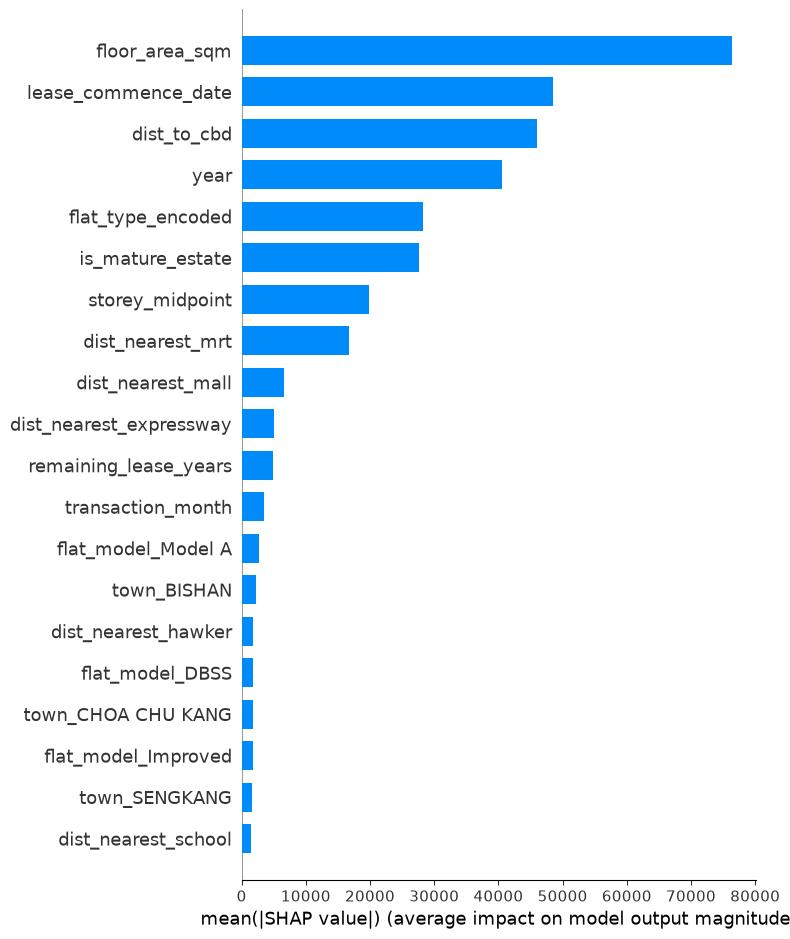

In [13]:
explainer = shap.TreeExplainer(model_geo)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=20)

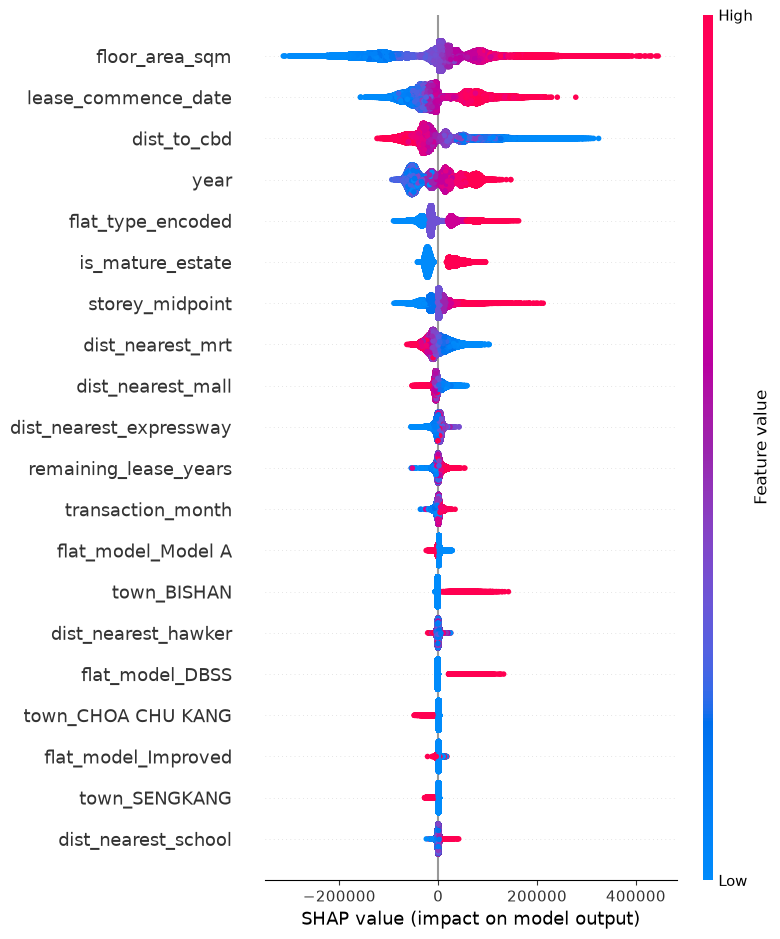

In [14]:
shap.summary_plot(shap_values, X_train, plot_type="dot", max_display=20)

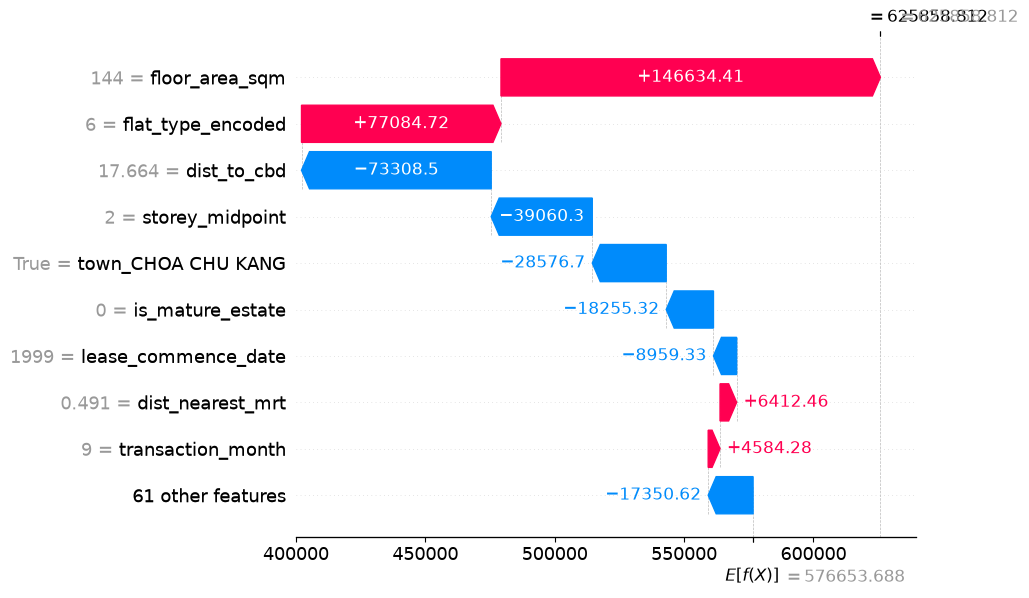

In [15]:
shap_values_exp = explainer(X_train.iloc[[0]])
shap.plots.waterfall(shap_values_exp[0])

## Quantile Regression
We train three quantile regression models with early stopping to produce confidence intervals around each prediction. As in notebook 03, `quantile_alpha` values of 0.1, 0.5 and 0.9 correspond to the lower bound, median estimate and upper bound respectively.

Unlike notebook 03 where `n_estimators` was fixed at 500, here we set `n_estimators=2000` with `early_stopping_rounds=50` to allow each quantile model to converge naturally.

In [16]:
quantiles = [0.1, 0.5, 0.9]
quantile_models = {}

for q in quantiles:
    print(f"Training quantile {q} model...")
    model_q = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.1,
        max_depth=6,
        objective='reg:quantileerror',
        quantile_alpha=q,
        tree_method='hist',
        random_state=44,
        early_stopping_rounds=50,
    )
    model_q.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    quantile_models[q] = model_q
    print(f"  Done. Best iteration: {model_q.best_iteration}")

print("\nAll quantile models trained.")

Training quantile 0.1 model...
  Done. Best iteration: 1366
Training quantile 0.5 model...
  Done. Best iteration: 1514
Training quantile 0.9 model...
  Done. Best iteration: 764

All quantile models trained.


## Confidence Interval Validation
We inspect predictions on 5 test transactions to verify that the interval behaviour is sensible. Actual prices should fall within the lower and upper bounds for approximately 80% of transactions by construction.

In [17]:
sample = X_test.iloc[:5]

lower = quantile_models[0.1].predict(sample)
median = quantile_models[0.5].predict(sample)
upper = quantile_models[0.9].predict(sample)

for i in range(5):
    print(f"Transaction {i+1}:")
    print(f"  Actual:     ${y_test.iloc[i]:,.0f}")
    print(f"  Prediction: ${lower[i]:,.0f} — ${median[i]:,.0f} — ${upper[i]:,.0f}")
    print()

Transaction 1:
  Actual:     $375,542
  Prediction: $372,594 — $389,894 — $418,674

Transaction 2:
  Actual:     $696,791
  Prediction: $675,264 — $706,464 — $723,250

Transaction 3:
  Actual:     $933,857
  Prediction: $906,538 — $990,105 — $1,036,489

Transaction 4:
  Actual:     $804,135
  Prediction: $710,288 — $801,332 — $833,720

Transaction 5:
  Actual:     $797,020
  Prediction: $743,979 — $792,806 — $836,654



## Save Model Artifacts
We save all four geospatial models to `models/` for use by the FastAPI backend.

- `xgb_geo_baseline.json` — point prediction model trained on full geospatial feature set
- `xgb_geo_q10.json` — lower bound (10th percentile)
- `xgb_geo_q50.json` — median prediction (50th percentile)
- `xgb_geo_q90.json` — upper bound (90th percentile)

In [18]:
import os

os.makedirs('../models', exist_ok=True)

model_geo.save_model('../models/xgb_geo_baseline.json')
quantile_models[0.1].save_model('../models/xgb_geo_q10.json')
quantile_models[0.5].save_model('../models/xgb_geo_q50.json')
quantile_models[0.9].save_model('../models/xgb_geo_q90.json')

print("All models saved to models/")
print(f"  xgb_geo_baseline.json")
print(f"  xgb_geo_q10.json")
print(f"  xgb_geo_q50.json")
print(f"  xgb_geo_q90.json")

All models saved to models/
  xgb_geo_baseline.json
  xgb_geo_q10.json
  xgb_geo_q50.json
  xgb_geo_q90.json
